# Scaling, Normalisation & Transformation — putting columns on a comparable footing

01 Core Python · 02 Pandas · 03 Cleaning · **▶ 04 Transformation** · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`04_Data_Transformation/04_scaling_normalisation_and_transformation.ipynb`

---

### In one paragraph (no jargon)

Income runs to hundreds of thousands; age runs from 18 to 70; a satisfaction score runs 1 to 5. Any method that measures *distance* — clustering, KNN, PCA, regularised regression — will be dominated by income purely because its numbers are bigger, not because it matters more. Scaling fixes that. A separate problem is **skew**: when a column has a long tail, a log or square-root transform pulls it back toward symmetry, which is what most statistical methods assume.

### After this notebook you can

- Apply min-max normalisation, z-score standardisation and robust scaling
- Choose between them based on outliers and on what the next step needs
- Apply log, square-root and Box-Cox transforms to reduce skew
- Recognise which models need scaling and which are indifferent to it


### What's inside

1. Setup and first look
2. Min-max normalisation
3. Z-score standardisation
4. Logarithmic transformation
5. Square-root transformation
6. Comparing every transformation
7. ⚡ Which models actually need this
8. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_datatransform():
    """Exact copy of datatransform.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Col 1,col 2,col 3,col 4
9707,245,495276,0.019599173
8593,204,513860,0.016722454
9529,424,976523,0.009758091
4553,293,150696,0.030213144
1418,285,142106,0.009978467
2177,562,291927,0.007457344
6420,425,376294,0.017061128
3428,419,41079,0.083448964
8162,332,552404,0.014775418
6804,64,210861,0.032267702
8191,35,139886,0.058554823
7406,185,344554,0.021494454
3724,269,706162,0.005273577
9850,513,23912,0.411927066
9083,493,545820,0.016641017
3685,148,297762,0.012375656
8843,42,982045,0.009004679
6566,168,640013,0.010259167
7715,198,691130,0.011162878
1515,524,790161,0.001917331
3135,299,306379,0.010232425
6949,313,601510,0.011552593
9369,402,352329,0.026591623
5606,382,360539,0.015548942
4378,155,184293,0.02375565
4069,433,22867,0.177942013
2084,206,694982,0.002998639
6613,95,638725,0.010353438
3626,434,294901,0.012295652
1438,320,781703,0.001839573
3672,201,926132,0.003964878
6091,561,708592,0.00859592
2755,589,348879,0.007896721
5137,332,221951,0.023144748
6852,475,20091,0.341048231
5062,110,782530,0.006468762
2808,193,219351,0.0128014
6162,174,106706,0.057747456
3465,271,53833,0.064365724
6088,408,399737,0.015230014
2217,466,986505,0.002247328
7882,401,541300,0.014561241
5737,160,848977,0.006757545
6008,82,454784,0.013210667
5965,192,841934,0.007084878
1406,263,162971,0.008627302
7727,193,178138,0.043376483
1467,284,586650,0.002500639
7660,351,611745,0.012521557
3280,461,585995,0.005597317
9679,247,569444,0.016997282
6024,116,857874,0.00702201
7348,143,673015,0.010918033
9205,423,788505,0.011673991
5145,450,165641,0.03106115
6162,148,728922,0.008453579
7527,211,259257,0.029032967
6579,126,20132,0.326793165
3458,315,373908,0.009248264
7555,213,959691,0.007872326
4123,328,372852,0.011058007
8692,53,901420,0.009642564
8345,380,312754,0.026682313
6643,531,122120,0.054397314
9782,166,63810,0.153298856
7271,566,367859,0.019765725
3851,155,281509,0.013679847
4909,413,724052,0.0067799
9087,395,88130,0.103109043
5108,475,840992,0.00607378
8955,403,203290,0.044050371
1432,406,143177,0.010001606
6628,407,123955,0.053471018
2664,285,708749,0.003758735
9089,112,155182,0.058569937
5752,98,12052,0.477265184
6299,532,72152,0.087301807
4690,327,526742,0.00890379
6305,424,33515,0.18812472
4952,47,145136,0.034119722
2423,431,787245,0.003077822
8769,576,78863,0.111192828
1772,79,869458,0.002038051
5496,93,71393,0.076982337
2374,361,361657,0.006564231
5604,106,555710,0.010084397
6766,214,114519,0.059081899
4504,585,223796,0.020125471
6247,74,221987,0.028141288
4538,269,837589,0.005417932
8499,130,675427,0.012583151
4443,511,666679,0.006664377
7092,150,615236,0.011527284
5558,366,339753,0.016358943
9561,454,175890,0.054357837
4303,394,338913,0.012696474
1835,315,640929,0.002863032
7247,346,655521,0.011055329
2216,258,724158,0.003060106
7029,357,15782,0.445380814
6671,299,998240,0.006682762
9974,418,228505,0.043648935
7946,365,815931,0.009738569
9011,164,726461,0.012403969
5868,343,330628,0.017748043
9209,577,299266,0.030771955
1769,117,371928,0.004756297
8352,151,720255,0.011595893
8649,406,508333,0.017014437
8605,350,491255,0.017516361
3034,403,897142,0.00338185
5626,248,194910,0.028864604
5948,330,450105,0.013214694
3178,98,341550,0.009304641
8576,85,445058,0.019269399
5318,230,47285,0.112466956
4051,344,181769,0.022286529
9900,179,577793,0.017134164
6444,287,881167,0.007313029
2691,91,881619,0.003052339
2369,281,156382,0.015148802
7300,400,525483,0.013891981
8765,361,537137,0.016317997
5679,517,141922,0.040014938
9254,441,442390,0.020918194
8174,34,724983,0.011274747
4887,563,919392,0.005315469
2167,276,741654,0.002921848
5196,289,280125,0.018548862
9568,356,615817,0.015537083
1018,373,748364,0.001360301
7029,98,227453,0.030903088
1495,354,679025,0.002201686
6059,405,106700,0.05678538
1737,566,456632,0.003803938
7664,151,977123,0.007843434
4277,331,984901,0.004342568
5286,561,227591,0.023225874
5473,70,420826,0.013005375
2588,346,687979,0.003761743
2863,172,602072,0.004755245
7607,574,332040,0.02290989
2174,130,606495,0.003584531
9854,293,885918,0.011122926
2002,57,637978,0.003138039
5521,378,785463,0.007028975
5801,330,77708,0.074651259
5903,171,233871,0.02524041
8433,153,89179,0.094562621
7196,114,973399,0.007392652
5750,182,40822,0.140855421
8848,456,683741,0.012940573
8686,117,108037,0.080398382
4894,193,615745,0.007948095
2305,483,279621,0.008243301
3762,245,896944,0.004194242
3620,34,107667,0.033622187
6688,219,643087,0.010399837
2358,518,558758,0.004220074
1560,216,695126,0.002244197
1991,534,379741,0.005243047
2656,363,360875,0.007359889
9729,585,536961,0.018118634
1306,464,443348,0.002945767
7082,78,68892,0.102798583
5117,367,849665,0.006022374
2236,174,368557,0.006066904
8065,564,554333,0.014549017
7551,486,735134,0.010271597
2414,522,966697,0.002497163
5673,299,380246,0.014919289
7546,300,211173,0.035733735
5392,430,691117,0.007801863
7655,142,93471,0.081897059
2943,499,611393,0.004813598
4342,240,663436,0.006544716
3582,533,566631,0.006321574
4294,451,477561,0.008991522
3011,270,783574,0.003842649
5546,436,601207,0.009224776
8852,192,671070,0.013190874
6745,364,742010,0.009090174
4500,575,896607,0.005018921
4536,44,68476,0.066242187
3843,522,720381,0.005334677
7961,203,707430,0.01125341
2151,72,587871,0.003658966
3420,519,950489,0.003598148
5405,362,937558,0.005764977
3693,378,875818,0.004216629
1554,226,463056,0.003355966
5579,523,496579,0.011234869
6268,545,742111,0.008446176
1182,468,185082,0.006386358
7343,80,522334,0.014058055
2496,496,355911,0.007012989
1082,96,76055,0.014226547
1062,424,359577,0.00295347
2785,435,409913,0.006794125
2135,118,564044,0.003785166
8590,146,589694,0.014566877
1915,334,495294,0.00386639
5222,311,773170,0.006754013
6607,132,523628,0.012617736
3422,109,832699,0.004109528
5761,416,160218,0.035957258
9702,399,421017,0.0230442
4813,531,633224,0.007600786
5471,437,97668,0.0560163"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Feature Scaling & Normalization — A Complete Reference

**Dataset:** `datatransform.csv` — 209 rows, 4 numeric columns on wildly different scales (`Col 1` in the thousands, `col 3` in the hundreds of thousands, `col 4` a small decimal fraction). This is exactly the kind of data where scaling matters: any distance-based or gradient-based algorithm (KNN, K-Means, SVMs, neural networks, regularized regression) will let the largest-magnitude column dominate unless every column is put on a comparable footing first.

We'll cover every major technique, grouped by what it's actually trying to fix:

**Scaling techniques** (change the *range*, not the *shape*, of the distribution)
1. Min-Max Scaling
2. Standardization (Z-score scaling)
3. Robust Scaling
4. MaxAbs Scaling
5. Normalizer (unit-vector / row-wise scaling)

**Transformation techniques** (change the *shape* of the distribution, usually to reduce skew)
6. Log transform
7. Square-root transform
8. Box-Cox transform
9. Yeo-Johnson transform
10. Quantile Transformer (uniform & normal output)

## 1. Setup & first look

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams['figure.dpi'] = 100

df = load_data('datatransform.csv', rebuild=rebuild_datatransform)
df.columns = [c.strip() for c in df.columns]
print(f"Shape: {df.shape}")
df.describe().round(3)

Loaded 'datatransform.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (209, 4)


,Col 1,col 2,col 3,col 4
count,209.000,209.000,209.000,209.000
mean,5485.493,308.541,480151.139,0.031
std,2515.139,155.698,281777.682,0.066
min,1018.000,34.000,12052.000,0.001
25%,3422.000,171.000,221987.000,0.007
50%,5604.000,320.000,496579.000,0.011
75%,7546.000,425.000,707430.000,0.023
max,9974.000,589.000,998240.000,0.477


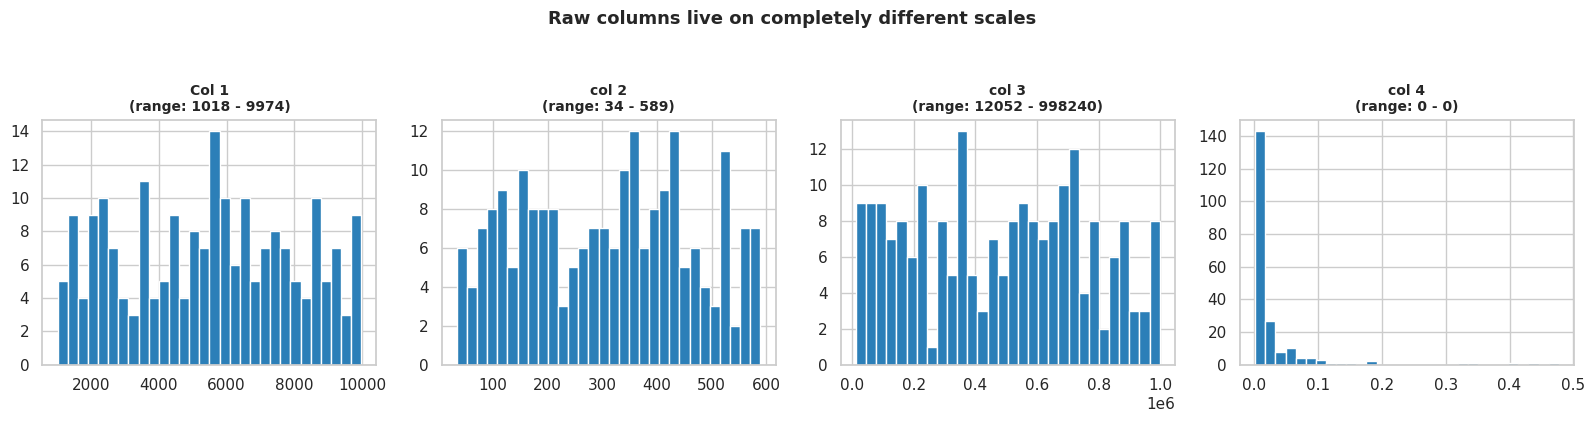

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, df.columns):
    ax.hist(df[col], bins=30, color='#2c7fb8', edgecolor='white')
    ax.set_title(f"{col}\n(range: {df[col].min():.0f} - {df[col].max():.0f})", fontsize=10, fontweight='bold')
plt.suptitle('Raw columns live on completely different scales', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 2. Min-Max Scaling
Squeezes every value into a fixed `[0, 1]` range: `(x - min) / (max - min)`. Simple and preserves the original distribution's *shape* exactly — but very sensitive to outliers, since a single extreme value stretches the whole range and compresses everything else.

In [4]:
from sklearn.preprocessing import MinMaxScaler

# WHAT: squashes every value into the range 0-1 using (x - min) / (max - min).
# WATCH OUT: one extreme value sets the max, squashing everything else into a tiny band.
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=df.columns)
print("After Min-Max scaling, every column is now bounded in [0, 1]:")
df_minmax.describe().round(3).loc[['min', 'max', 'mean']]

After Min-Max scaling, every column is now bounded in [0, 1]:


,Col 1,col 2,col 3,col 4
min,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000
mean,0.499,0.495,0.475,0.062


## 3. Standardization (Z-score scaling)
Centers each column at **mean 0** with **standard deviation 1**: `(x - mean) / std`. The default choice for most linear models and PCA, since it puts every feature on a comparable footing without bounding the range.

In [5]:
from sklearn.preprocessing import StandardScaler

# WHAT: rescales to mean 0, standard deviation 1, using (x - mean) / std.
# The result is a z-score: 'how many standard deviations from average is this?'
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df), columns=df.columns)
print("After standardization, every column has mean ~0, std ~1:")
df_standard.describe().round(3).loc[['mean', 'std', 'min', 'max']]

After standardization, every column has mean ~0, std ~1:


,Col 1,col 2,col 3,col 4
mean,-0.000,0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002
min,-1.781,-1.768,-1.665,-0.451
max,1.789,1.806,1.843,6.795


## 4. Robust Scaling
Uses the **median** and **IQR** instead of mean/std: `(x - median) / IQR`. Built specifically to resist distortion from outliers, since median/IQR barely move even with a handful of extreme values — unlike Min-Max or Standard scaling.

In [6]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
df_robust = pd.DataFrame(robust_scaler.fit_transform(df), columns=df.columns)
df_robust.describe().round(3).loc[['mean', 'std', 'min', 'max']]

,Col 1,col 2,col 3,col 4
mean,-0.029,-0.045,-0.034,1.189
std,0.610,0.613,0.580,3.966
min,-1.112,-1.126,-0.998,-0.597
max,1.060,1.059,1.033,28.072


## 5. MaxAbs Scaling
Divides by the maximum **absolute** value, mapping data into `[-1, 1]`. Behaves like Min-Max but preserves zero as zero and handles negative values naturally — a good fit for sparse data (e.g. TF-IDF matrices) where you don't want to shift the zero point.

In [7]:
from sklearn.preprocessing import MaxAbsScaler

maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df), columns=df.columns)
df_maxabs.describe().round(3).loc[['min', 'max']]

,Col 1,col 2,col 3,col 4
min,0.102,0.058,0.012,0.003
max,1.000,1.000,1.000,1.000


## 6. Normalizer (unit-vector / row-wise scaling)
This is fundamentally different from every method above: instead of rescaling each **column**, it rescales each **row** so that the row's vector has length 1 (by default, Euclidean/L2 norm). Common in text mining and any setting where you care about the *direction* of a row's feature vector rather than its absolute magnitude.

In [8]:
from sklearn.preprocessing import Normalizer

row_normalizer = Normalizer(norm='l2')
df_row_normalized = pd.DataFrame(row_normalizer.fit_transform(df), columns=df.columns)

# Verify: each ROW's vector now has length 1 (sum of squares = 1)
row_lengths = np.sqrt((df_row_normalized ** 2).sum(axis=1))
print("Sample of row vector lengths after L2 row-normalization (should all be ~1.0):")
print(row_lengths.head().round(4).tolist())

Sample of row vector lengths after L2 row-normalization (should all be ~1.0):
[1.0, 1.0, 1.0, 1.0, 1.0]


## 7. Scaling techniques — visual comparison
All five methods below preserve the *shape* of the distribution (they're all linear transforms of a single column) — what changes is the **range** and how much **outliers get squashed**.

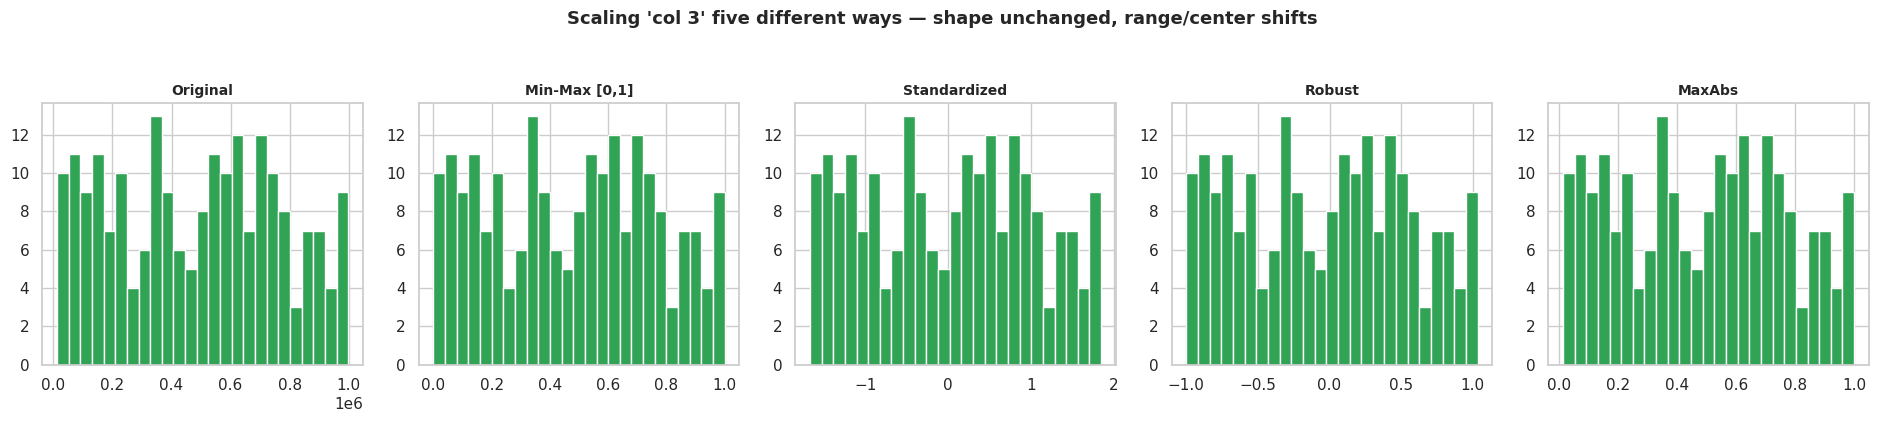

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4))
target_col = 'col 3'  # the column with the widest raw range -- easiest to see the effect
data_sets = [
    ('Original', df[target_col]),
    ('Min-Max [0,1]', df_minmax[target_col]),
    ('Standardized', df_standard[target_col]),
    ('Robust', df_robust[target_col]),
    ('MaxAbs', df_maxabs[target_col]),
]
for ax, (title, series) in zip(axes, data_sets):
    ax.hist(series, bins=25, color='#31a354', edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
plt.suptitle(f"Scaling '{target_col}' five different ways — shape unchanged, range/center shifts",
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 8. Transformations that change the SHAPE of the distribution
Scaling alone can't fix **skew** — a right-skewed column stays right-skewed no matter how you rescale it. For that, you need a genuine mathematical transform. We'll use `col 4`, the most skewed column (values cluster near 0 with a long right tail).

In [10]:
from scipy import stats as sp_stats

col = 'col 4'
print(f"Original '{col}' skewness: {df[col].skew():.2f}  (0 = perfectly symmetric; this is heavily right-skewed)")

# --- Log transform ---
log_transformed = np.log1p(df[col])  # log1p = log(1+x), safely handles values near zero

# --- Square-root transform (gentler than log) ---
sqrt_transformed = np.sqrt(df[col])

# --- Box-Cox (finds the best power transform automatically; requires strictly positive data) ---
boxcox_transformed, boxcox_lambda = sp_stats.boxcox(df[col])
print(f"Box-Cox chose lambda = {boxcox_lambda:.3f} (lambda=0 is equivalent to a log transform)")

# --- Yeo-Johnson (Box-Cox's generalization that also works with zero/negative values) ---
from sklearn.preprocessing import PowerTransformer
yeo_johnson = PowerTransformer(method='yeo-johnson')
yeo_transformed = yeo_johnson.fit_transform(df[[col]]).flatten()

for name, arr in [('Log (log1p)', log_transformed), ('Square-root', sqrt_transformed),
                  ('Box-Cox', boxcox_transformed), ('Yeo-Johnson', yeo_transformed)]:
    print(f"{name:15s} -> skewness after transform: {pd.Series(arr).skew():.3f}")

Original 'col 4' skewness: 4.80  (0 = perfectly symmetric; this is heavily right-skewed)
Box-Cox chose lambda = -0.248 (lambda=0 is equivalent to a log transform)
Log (log1p)     -> skewness after transform: 4.454
Square-root     -> skewness after transform: 2.799
Box-Cox         -> skewness after transform: 0.030
Yeo-Johnson     -> skewness after transform: 0.981


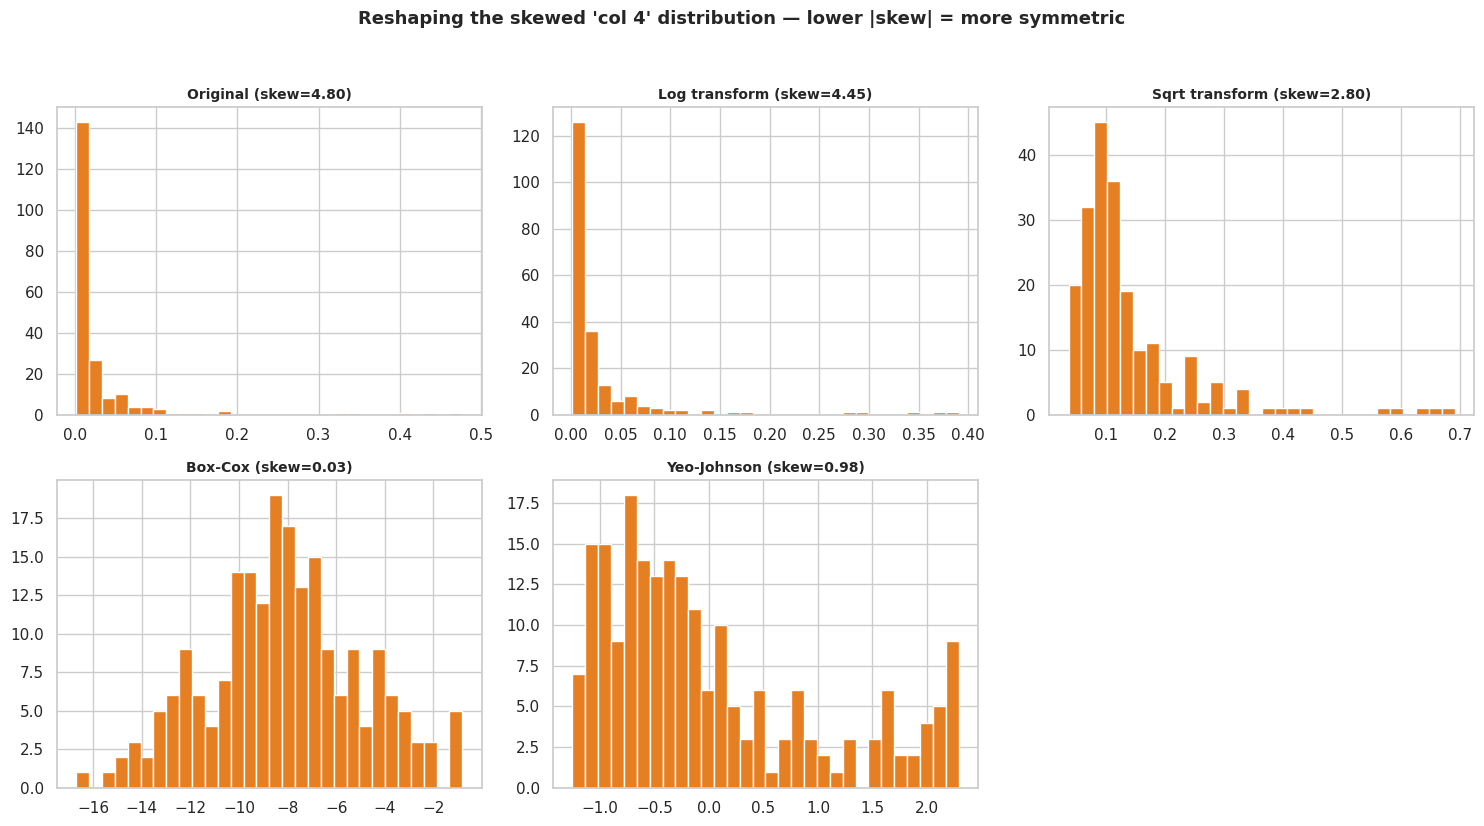

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plots = [
    ('Original (skew={:.2f})'.format(df[col].skew()), df[col]),
    ('Log transform (skew={:.2f})'.format(pd.Series(log_transformed).skew()), log_transformed),
    ('Sqrt transform (skew={:.2f})'.format(pd.Series(sqrt_transformed).skew()), sqrt_transformed),
    ('Box-Cox (skew={:.2f})'.format(pd.Series(boxcox_transformed).skew()), boxcox_transformed),
    ('Yeo-Johnson (skew={:.2f})'.format(pd.Series(yeo_transformed).skew()), yeo_transformed),
]
for ax, (title, arr) in zip(axes, plots):
    ax.hist(arr, bins=30, color='#e67e22', edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
axes[-1].axis('off')
plt.suptitle(f"Reshaping the skewed '{col}' distribution — lower |skew| = more symmetric",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 9. Quantile Transformer
Maps a column to follow a **uniform** or **normal** distribution exactly, by mapping each value to its rank/percentile and then to the target distribution's corresponding value. The most aggressive reshaping tool here — very effective against skew, but note it's a non-linear, rank-based transform, so it can distort the relative distance between close values.

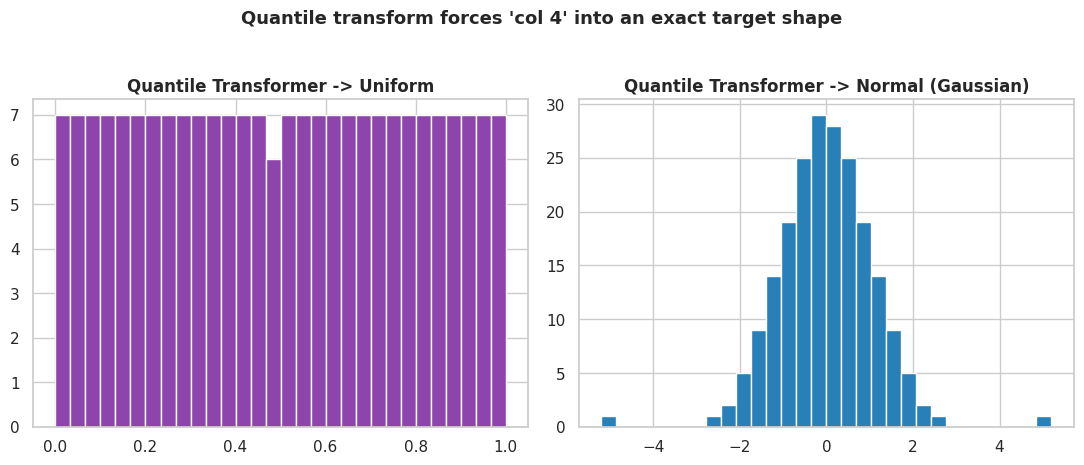

In [12]:
from sklearn.preprocessing import QuantileTransformer

qt_uniform = QuantileTransformer(output_distribution='uniform', n_quantiles=len(df), random_state=42)
qt_normal = QuantileTransformer(output_distribution='normal', n_quantiles=len(df), random_state=42)

col4_uniform = qt_uniform.fit_transform(df[[col]]).flatten()
col4_normal = qt_normal.fit_transform(df[[col]]).flatten()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(col4_uniform, bins=30, color='#8e44ad', edgecolor='white')
axes[0].set_title("Quantile Transformer -> Uniform", fontweight='bold')
axes[1].hist(col4_normal, bins=30, color='#2980b9', edgecolor='white')
axes[1].set_title("Quantile Transformer -> Normal (Gaussian)", fontweight='bold')
plt.suptitle(f"Quantile transform forces '{col}' into an exact target shape", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Key takeaways

| Technique | Changes range? | Changes shape? | Outlier-robust? | Typical use |
|---|---|---|---|---|
| Min-Max | Yes -> [0,1] | No | No | Neural nets, algorithms needing bounded input |
| Standardization | Yes -> mean 0, std 1 | No | No | Linear/logistic regression, PCA, SVM |
| Robust Scaler | Yes -> median 0 | No | **Yes** | Data with known outliers |
| MaxAbs | Yes -> [-1,1] | No | No | Sparse data, preserving zero |
| Normalizer (row-wise) | Yes, per-row | No | No | Text/TF-IDF, direction-sensitive tasks |
| Log / sqrt | No | Yes (reduces right-skew) | Somewhat | Right-skewed positive data |
| Box-Cox | No | Yes (optimal power transform) | Somewhat | Strictly positive skewed data |
| Yeo-Johnson | No | Yes (optimal power transform) | Somewhat | Skewed data that may include zero/negative values |
| Quantile Transformer | Yes | Yes (forces exact target shape) | **Very** | Heavily non-normal data, tree-insensitive pipelines |

**Rule of thumb:** scale for algorithms sensitive to feature magnitude (distance/gradient-based); transform for algorithms sensitive to distributional shape (linear models assuming normality); tree-based models (Random Forest, XGBoost) generally need **neither**, since they split on ranks, not raw magnitudes.

### ⚡ Beyond the syllabus — which models actually need scaling — and what skew does to a regression

Scaling is not always necessary, and knowing when to skip it is as useful as knowing how to do it. Anything measuring distance or applying a penalty needs it; tree-based models are completely indifferent because they only ask "is this value above or below the split point?". The second half of this cell shows the more interesting effect: fixing skew can change a model's fit far more than scaling ever does.

In [13]:
print("""
NEEDS SCALING                             INDIFFERENT TO SCALING
  KNN, K-means             (distances)      Decision Tree
  SVM                      (distances)      Random Forest
  PCA                      (variances)      Gradient Boosting / XGBoost
  Ridge / Lasso            (penalty)        Plain linear regression*
  Neural networks          (gradients)      Naive Bayes
  Logistic regression      (convergence)

  * coefficients change meaning with scale, but predictions and R-squared do not.
""")

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer

data = load_data('datatransform.csv', rebuild=rebuild_datatransform)
col = data.select_dtypes('number').columns[2]
x = data[[col]].dropna()

scalers = {'MinMax (0-1)': MinMaxScaler(),
           'Standard (z-score)': StandardScaler(),
           'Robust (median/IQR)': RobustScaler(),
           'Yeo-Johnson (power)': PowerTransformer(method='yeo-johnson')}

print(f"Column '{col}' under each scaler:\n")
print(f"{'SCALER':<24}{'MIN':>10}{'MAX':>10}{'MEAN':>10}{'STD':>10}{'SKEW':>9}")
print("-" * 73)
print(f"{'(original)':<24}{x[col].min():>10.2f}{x[col].max():>10.2f}"
      f"{x[col].mean():>10.2f}{x[col].std():>10.2f}{stats.skew(x[col]):>9.2f}")
for name, scaler in scalers.items():
    out = pd.Series(scaler.fit_transform(x).ravel())
    print(f"{name:<24}{out.min():>10.2f}{out.max():>10.2f}{out.mean():>10.2f}"
          f"{out.std():>10.2f}{stats.skew(out):>9.2f}")

print("""
READ THE LAST COLUMN. MinMax, Standard and Robust all change the SCALE but leave the
SKEW almost untouched — they are linear transformations, so the shape is preserved.
Only a power transform (log, sqrt, Box-Cox, Yeo-Johnson) changes the shape itself.
If your problem is 'the units are different', scale. If it's 'the distribution has a
long tail', transform. They are different problems with different fixes.""")


NEEDS SCALING                             INDIFFERENT TO SCALING
  KNN, K-means             (distances)      Decision Tree
  SVM                      (distances)      Random Forest
  PCA                      (variances)      Gradient Boosting / XGBoost
  Ridge / Lasso            (penalty)        Plain linear regression*
  Neural networks          (gradients)      Naive Bayes
  Logistic regression      (convergence)

  * coefficients change meaning with scale, but predictions and R-squared do not.

Loaded 'datatransform.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Column 'col 3' under each scaler:

SCALER                         MIN       MAX      MEAN       STD     SKEW
-------------------------------------------------------------------------
(original)                12052.00 998240.00 480151.14 281777.68     0.02
MinMax (0-1)                  0.00      1.00      0.47      0.29     0.02
Standard (z-score)           -1.67      1.84     -0.00      1.00     0.02


Skew of 'spend'      : 3.32   (0 would be symmetric)
Skew after log1p     : 0.00

R² using raw spend   : 0.4792
R² using log(spend)  : 0.7684
-> the log transform alone improved fit by 28.9 percentage points,
   because the true relationship was logarithmic, not linear.


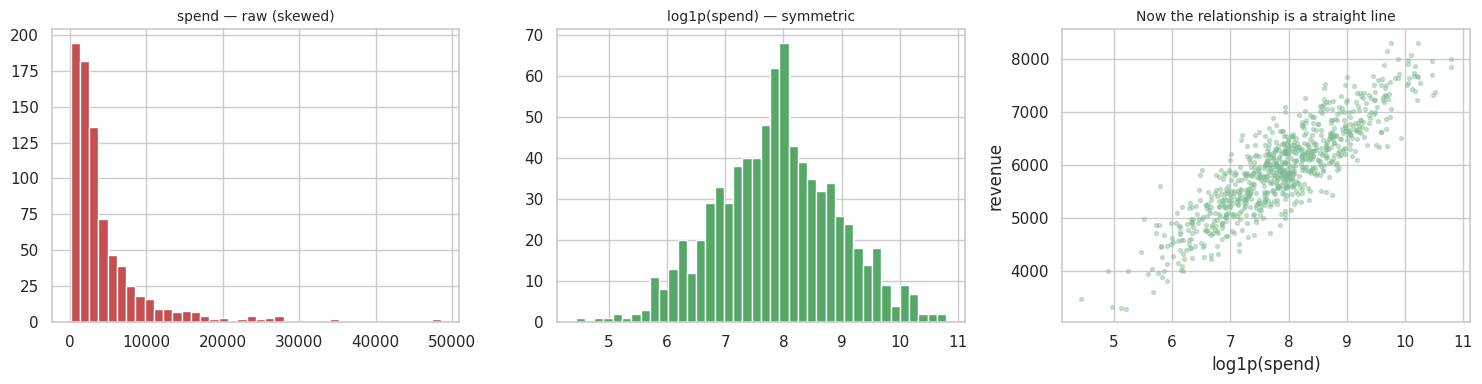


🔧 np.log1p(x) computes log(1 + x), so it works when x is 0. Plain np.log(0) is -inf.


In [14]:
# What fixing skew actually buys you, measured
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(7)
n = 800
spend = rng.lognormal(mean=8, sigma=1.1, size=n)                 # heavily right-skewed, like real spend
revenue = 250 + 1.8 * np.log(spend) * 400 + rng.normal(0, 400, n)
frame = pd.DataFrame({'spend': spend, 'revenue': revenue})

raw_r2 = cross_val_score(LinearRegression(), frame[['spend']], frame['revenue'],
                         cv=5, scoring='r2').mean()
log_r2 = cross_val_score(LinearRegression(), np.log1p(frame[['spend']]), frame['revenue'],
                         cv=5, scoring='r2').mean()

print(f"Skew of 'spend'      : {stats.skew(frame['spend']):.2f}   (0 would be symmetric)")
print(f"Skew after log1p     : {stats.skew(np.log1p(frame['spend'])):.2f}\n")
print(f"R² using raw spend   : {raw_r2:.4f}")
print(f"R² using log(spend)  : {log_r2:.4f}")
print(f"-> the log transform alone improved fit by {(log_r2-raw_r2)*100:.1f} percentage points,")
print("   because the true relationship was logarithmic, not linear.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(frame['spend'], bins=40, color='#c44e52'); axes[0].set_title('spend — raw (skewed)', fontsize=10)
axes[1].hist(np.log1p(frame['spend']), bins=40, color='#55a868'); axes[1].set_title('log1p(spend) — symmetric', fontsize=10)
axes[2].scatter(np.log1p(frame['spend']), frame['revenue'], s=8, alpha=.4)
axes[2].set_title('Now the relationship is a straight line', fontsize=10)
axes[2].set_xlabel('log1p(spend)'); axes[2].set_ylabel('revenue')
plt.tight_layout(); plt.show()

print("\n🔧 np.log1p(x) computes log(1 + x), so it works when x is 0. Plain np.log(0) is -inf.")

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Min-max to 0–1 | `MinMaxScaler().fit_transform(df[['c']])` |
| Min-max by hand | `(s - s.min()) / (s.max() - s.min())` |
| Z-score | `StandardScaler().fit_transform(df[['c']])` |
| Z-score by hand | `(s - s.mean()) / s.std()` |
| Outlier-resistant | `RobustScaler()` |
| Natural log | `np.log1p(s)` |
| Log base 10 | `np.log10(s + 1)` |
| Square root | `np.sqrt(s)` |
| Box-Cox / Yeo-Johnson | `PowerTransformer(method='yeo-johnson')` |
| Measure skew | `scipy.stats.skew(s)` |
| Undo a scaling | `scaler.inverse_transform(x)` |

### Adapting this in the exam

- 'Normalise' usually means min-max to 0–1; 'standardise' means z-score. If the question is ambiguous, do both and say which is which.
- 'The data is skewed' → log or square-root transform, and show the skew before and after.
- 'Prepare the features for KNN/clustering/PCA' → standardise, because those methods measure distance.

### Traps that cost marks

- `fit_transform` on **training** data, `transform` on test. Fitting the scaler on everything leaks test information.
- sklearn scalers need a 2-D input: `df[['col']]`, not `df['col']`.
- MinMax is destroyed by a single outlier — it sets the maximum and squashes everything else. Use `RobustScaler` when outliers are present.
- `np.log(0)` is `-inf` and `np.log(negative)` is `NaN`. Use `np.log1p` or shift the column first.
- Scaling does **not** fix skew and transforming does **not** standardise units — they're different problems.
- A scaled column is no longer in rupees or years. Keep the original for reporting; use the scaled one for modelling.